# <br><center> Exploring the paired T-test using cross validation

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.figsize": (14,8),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.2
})

import scipy.stats as stats
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.datasets import load_diabetes

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from dotenv import load_dotenv
load_dotenv()

import gc; gc.enable()
from IPython.display import clear_output, display
from tqdm.notebook import tqdm

print("setup done!")

setup done!


In [2]:
# load data
ds = load_diabetes()
desc = ds["DESCR"]

X = ds["data"]
y = ds["target"]

X, x_test = train_test_split(X, test_size=0.2, random_state=67)
y, y_test = train_test_split(y, test_size=0.2, random_state=67)

del ds; gc.collect()
print(desc)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
# cross validation
model1 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3,
    early_stopping_rounds=30,
    random_state=67
)

model2 = CatBoostRegressor(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3,
    early_stopping_rounds=30,
    random_state=67,
)

n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=67)

xs = np.zeros(n_splits)
ys = np.zeros(n_splits)
for fold, (train_idx, val_idx) in enumerate(tqdm(kf.split(X), desc="Model Evaluation", leave=False)):
    x_train, y_train = X[train_idx], y[train_idx]
    x_val, y_val = X[val_idx], y[val_idx]

    model1.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_val, y_val)], verbose=100)
    model2.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_val, y_val)], verbose=100)

    y_pred_1 = model1.predict(x_val)
    y_pred_2 = model2.predict(x_val)

    xs[fold] = root_mean_squared_error(y_val, y_pred_1)
    ys[fold] = root_mean_squared_error(y_val, y_pred_2)


Model Evaluation: 0it [00:00, ?it/s]

[0]	validation_0-rmse:79.18909	validation_1-rmse:68.27243
[99]	validation_0-rmse:55.19739	validation_1-rmse:63.17004
0:	learn: 79.2450792	test: 79.2450792	test1: 68.2682148	best: 68.2682148 (0)	total: 58.8ms	remaining: 11.7s
100:	learn: 60.5070216	test: 60.5070216	test1: 61.3174139	best: 61.3093801 (97)	total: 72ms	remaining: 70.6ms
Stopped by overfitting detector  (30 iterations wait)

bestTest = 60.74624407
bestIteration = 165

Shrink model to first 166 iterations.
[0]	validation_0-rmse:79.39578	validation_1-rmse:66.04929
[100]	validation_0-rmse:56.47231	validation_1-rmse:49.74969
[199]	validation_0-rmse:48.06267	validation_1-rmse:47.70716
0:	learn: 79.5198477	test: 79.5198477	test1: 66.1005239	best: 66.1005239 (0)	total: 175us	remaining: 34.9ms
100:	learn: 62.2032110	test: 62.2032110	test1: 50.2783739	best: 50.2783739 (100)	total: 23ms	remaining: 22.5ms
199:	learn: 55.9304649	test: 55.9304649	test1: 45.8015443	best: 45.8015443 (199)	total: 44.9ms	remaining: 0us

bestTest = 45.801544

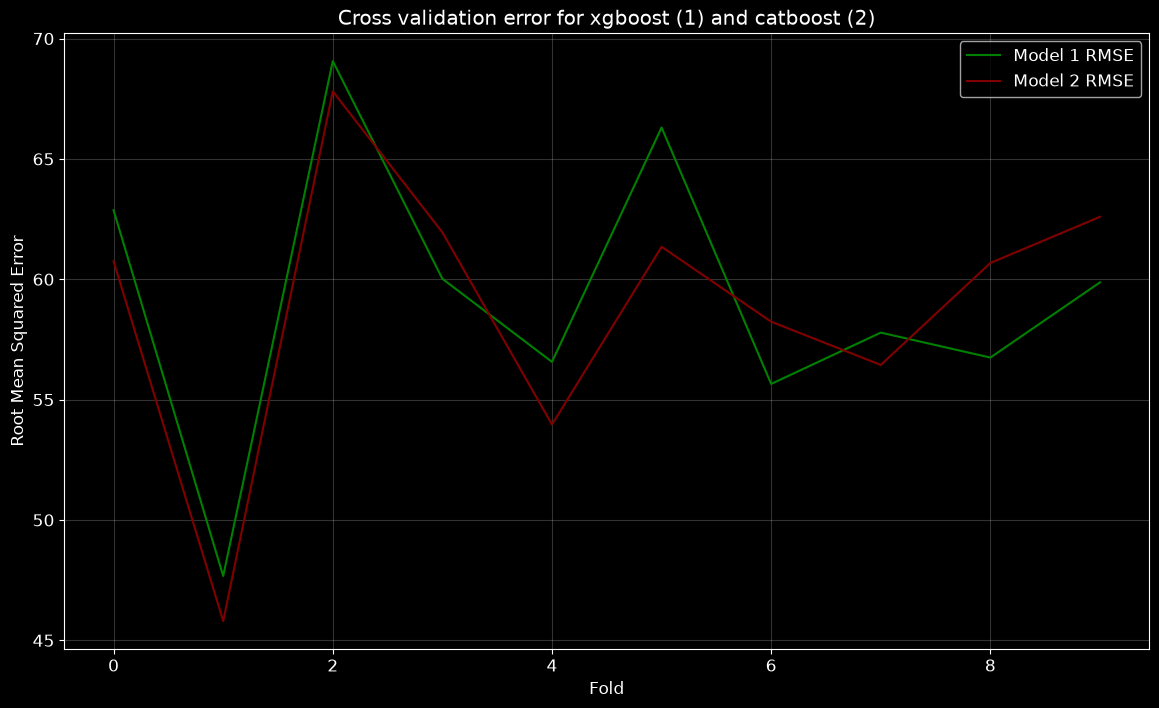

In [4]:
plt.plot(xs, color="green", label="Model 1 RMSE")
plt.plot(ys, color="maroon", label="Model 2 RMSE")
plt.title("Cross validation error for xgboost (1) and catboost (2)")
plt.xlabel("Fold")
plt.ylabel("Root Mean Squared Error")
plt.legend()
plt.show()

In [5]:
# paired t-test
results = stats.ttest_1samp(xs - ys, popmean=0)
print(f"T-test results: t={results.statistic:.4f}, p={results.pvalue:.8f}, df={int(results.df)}")

T-test results: t=0.3272, p=0.75099697, df=9


### Conclusion 1
Looking at the results of the t-test, we see that as our $p$-value was greater than 0.05, the experiment is inconclusive as of now, <br> and we need more data to effectively support that one model is better than the other.

In [6]:
# cross validation
model1 = XGBRegressor(
    early_stopping_rounds=30,
    random_state=67
)

model2 = LGBMRegressor(
    early_stopping_rounds=30,
    random_state=67,
    verbose=-100
)

n_splits = 25
kf = KFold(n_splits=n_splits, shuffle=True, random_state=67)

xs = np.zeros(n_splits)
ys = np.zeros(n_splits)
for fold, (train_idx, val_idx) in enumerate(tqdm(kf.split(X), desc="Model Evaluation", leave=False)):
    x_train, y_train = X[train_idx], y[train_idx]
    x_val, y_val = X[val_idx], y[val_idx]

    model1.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_val, y_val)], verbose=100)
    model2.fit(x_train, y_train, eval_X=(x_train, x_val), eval_y=(y_train, y_val))

    y_pred_1 = model1.predict(x_val)
    y_pred_2 = model2.predict(x_val)

    xs[fold] = root_mean_squared_error(y_val, y_pred_1)
    ys[fold] = root_mean_squared_error(y_val, y_pred_2)

Model Evaluation: 0it [00:00, ?it/s]

[0]	validation_0-rmse:63.14822	validation_1-rmse:60.78015
[31]	validation_0-rmse:5.98823	validation_1-rmse:62.38566
[0]	validation_0-rmse:62.41523	validation_1-rmse:75.64718
[30]	validation_0-rmse:5.85238	validation_1-rmse:98.76607
[0]	validation_0-rmse:63.77430	validation_1-rmse:40.32455
[31]	validation_0-rmse:5.82921	validation_1-rmse:45.32778
[0]	validation_0-rmse:63.29676	validation_1-rmse:61.17024
[49]	validation_0-rmse:2.12590	validation_1-rmse:55.03098
[0]	validation_0-rmse:62.05172	validation_1-rmse:67.52532
[31]	validation_0-rmse:5.03873	validation_1-rmse:68.64507
[0]	validation_0-rmse:62.76852	validation_1-rmse:67.68409
[32]	validation_0-rmse:6.11725	validation_1-rmse:65.33257
[0]	validation_0-rmse:62.19931	validation_1-rmse:88.73810
[33]	validation_0-rmse:5.47675	validation_1-rmse:80.90104
[0]	validation_0-rmse:63.21680	validation_1-rmse:69.90596
[30]	validation_0-rmse:6.46080	validation_1-rmse:86.19535
[0]	validation_0-rmse:62.49143	validation_1-rmse:78.84689
[53]	validatio

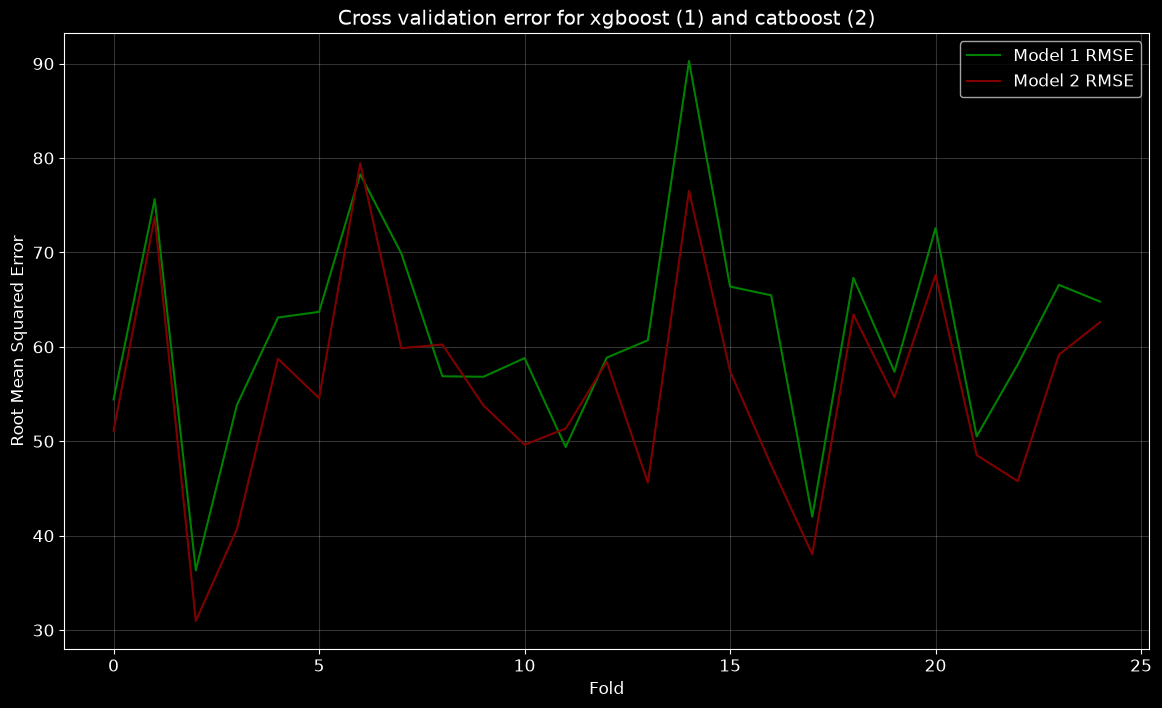

In [7]:
plt.plot(xs, color="green", label="Model 1 RMSE")
plt.plot(ys, color="maroon", label="Model 2 RMSE")
plt.title("Cross validation error for xgboost (1) and catboost (2)")
plt.xlabel("Fold")
plt.ylabel("Root Mean Squared Error")
plt.legend()
plt.show()

In [8]:
# paired t-test
results = stats.ttest_1samp(xs - ys, popmean=0)
print(f"T-test results: t={results.statistic:.4f}, p={results.pvalue:.8f}, df={int(results.df)}")

T-test results: t=5.3378, p=0.00001771, df=24


### Conclusion 2
Looking now at the new data, we see that in our new experiment, the lightgbm regressor outperforms the XGBRegressor as suggested by our t-test.

The $p$-value suggests extremely high levels of statistical significance, which is strong evidence that the gradient booster performed best on this dataset.

In [10]:
# test both models on actual test set:
model1 = XGBRegressor(
    random_state=67
)

model2 = LGBMRegressor(
    random_state=67,
    verbose=-1
)


model1.fit(X, y, verbose=0)
model2.fit(X, y)

y_pred_1 = model1.predict(x_test)
y_pred_2 = model2.predict(x_test)

rmse_1 = root_mean_squared_error(y_test, y_pred_1)
rmse_2 = root_mean_squared_error(y_test, y_pred_2)

print("Test set - final evaluation")
print(f"XGBoost: RMSE={rmse_1:.2f}, LightGBM: RMSE={rmse_2:.2f}")

Test set - final evaluation
XGBoost: RMSE=54.90, LightGBM: RMSE=51.00


### Our findings were correct!
As expected, our LightGBM regressor did better on the test-set for this data. <br> If it had thus been our real-world data, then we would have picked the correct model by trusting our t-test above.